In [3]:
import sys
sys.path.append("../src")

import matplotlib.pyplot as plt
import pandas as pd

from load_data import load_data
from models import linear_regression_model_base, linear_regression_model_lag, lasso_regression_model, decision_tree_regression_model, random_forest_regression_model
from features import TARGET_VARIABLE
from sklearn.model_selection import train_test_split

data = load_data()
X = data.drop(["index", "Date", "Season", TARGET_VARIABLE], axis=1, errors="ignore")
y = data[TARGET_VARIABLE]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

base_linear_model = linear_regression_model_base()
base_linear_model.fit(X_train[["AQHI"]], y_train)
y_pred_base = base_linear_model.predict(X_test[["AQHI"]])

linear_model = linear_regression_model_lag()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

lasso_model = lasso_regression_model()
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

DT_model = decision_tree_regression_model()
DT_model.fit(X_train, y_train)
y_pred_DT = DT_model.predict(X_test)

RF_model = random_forest_regression_model()
RF_model.fit(X_train, y_train)
y_pred_RF = RF_model.predict(X_test)

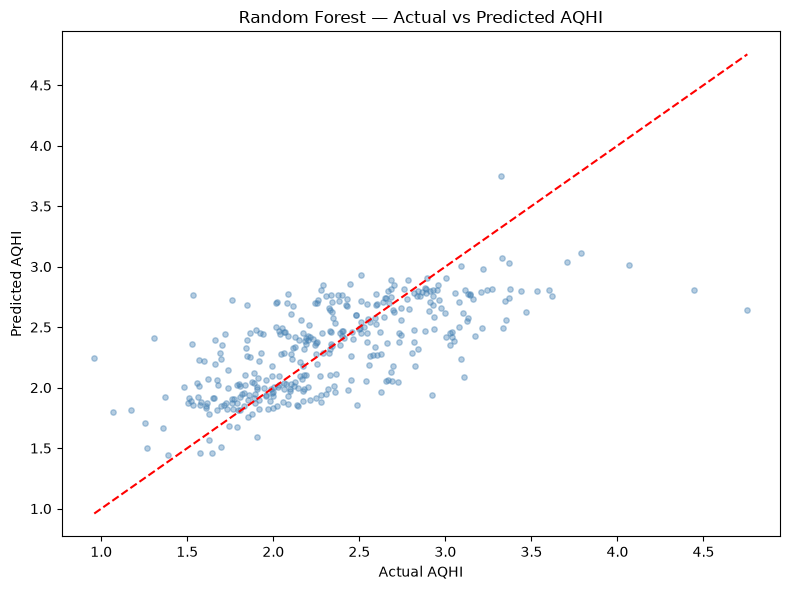

In [ ]:
# Load results (run after train.py has populated y_test and predictions)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_RF, alpha=0.4, s=15, color="steelblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
'r--', linewidth=1.5)
plt.xlabel("Actual AQHI")
plt.ylabel("Predicted AQHI")
plt.title("Random Forest : Actual vs Predicted AQHI")
plt.tight_layout()
plt.savefig("../results/plots/random_forest.png", dpi=150)
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_base, alpha=0.4, s=15, color="steelblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
plt.xlabel("Actual AQHI")
plt.ylabel("Predicted AQHI")
plt.title("Baseline Linear Regression — Actual vs Predicted AQHI")
plt.tight_layout()
plt.savefig("../results/plots/baseline_linear.png", dpi=150)
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_linear, alpha=0.4, s=15, color="steelblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
plt.xlabel("Actual AQHI")
plt.ylabel("Predicted AQHI")
plt.title("Linear Regression with Lag Features — Actual vs Predicted AQHI")
plt.tight_layout()
plt.savefig("../results/plots/linear_lag.png", dpi=150)
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lasso, alpha=0.4, s=15, color="steelblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
plt.xlabel("Actual AQHI")
plt.ylabel("Predicted AQHI")
plt.title("Lasso Regression — Actual vs Predicted AQHI")
plt.tight_layout()
plt.savefig("../results/plots/lasso.png", dpi=150)
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_DT, alpha=0.4, s=15, color="steelblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
plt.xlabel("Actual AQHI")
plt.ylabel("Predicted AQHI")
plt.title("Decision Tree — Actual vs Predicted AQHI")
plt.tight_layout()
plt.savefig("../results/plots/decision_tree.png", dpi=150)
plt.show()